# 08 — Bakprófun, viðmið og mánaðarskýrsla (backtest, benchmarks, report — Phase 7)

The final phase: an honest pseudo-real-time backtest by horizon against the plan's
floors, an error decomposition showing *which block* drives misses, and the
monthly one-pager output. Expanding window, refit each jump-off on data through
t−1, aggregated with the weights published at t−1 — no look-ahead.


In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_rows", 250)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}" if abs(x) < 1e6 else f"{x:,.0f}")

# Okabe-Ito palette (colorblind-safe); recessive grid per house chart style
C = {"blue": "#0072B2", "orange": "#E69F00", "green": "#009E73",
     "red": "#D55E00", "pink": "#CC79A7", "sky": "#56B4E9", "black": "#222222"}
plt.rcParams.update({
    "figure.figsize": (11, 4.5), "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})


In [2]:
from vnv import backtest, ingest
head = ingest.load_headline()
bt = backtest.run_backtest(start="2025-01", max_h=12)
print(f"forecast rows: {len(bt)}   jump-offs: {bt.jump_off.nunique()}")


forecast rows: 150   jump-offs: 18


## RMSE by horizon — vs the seasonal-naive floor

The model beats the seasonal-naive floor at **every horizon h=2–12**. Only h=1 is
(slightly) worse — the airfare-gated miss we already diagnosed: airfares (~4%,
±10–20% swings) are still *collecting*, so at h=1 they run on the generic model.


,n,RMSE_model,RMSE_seasonal_naive,model beats floor
horizon,,,,
1,18,0.4020,0.3420,False
2,17,0.3400,0.3520,True
3,16,0.3450,0.3610,True
4,15,0.3560,0.3630,True
5,14,0.3630,0.3730,True
6,13,0.3730,0.3760,True
7,12,0.3890,0.3890,False
8,11,0.3670,0.3830,True
9,10,0.3820,0.4000,True


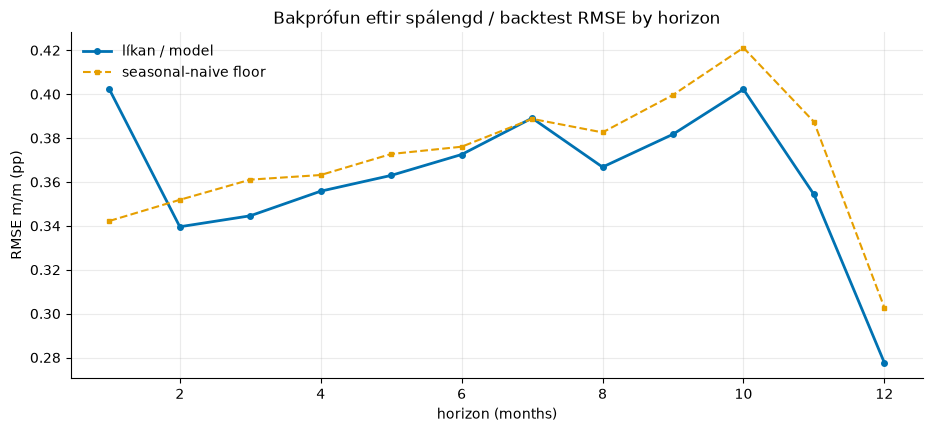

In [3]:
rbh = backtest.rmse_by_horizon(bt)
show = rbh[["n", "RMSE_model", "RMSE_seasonal_naive"]].copy()
show["model beats floor"] = show.RMSE_model < show.RMSE_seasonal_naive
display(show.round(3))

fig, ax = plt.subplots()
ax.plot(rbh.index, rbh.RMSE_model, color=C["blue"], lw=2, marker="o", ms=4, label="líkan / model")
ax.plot(rbh.index, rbh.RMSE_seasonal_naive, color=C["orange"], lw=1.5, ls="--", marker="s", ms=3,
        label="seasonal-naive floor")
ax.set_xlabel("horizon (months)"); ax.set_ylabel("RMSE m/m (pp)")
ax.set_title("Bakprófun eftir spálengd / backtest RMSE by horizon")
ax.legend(frameon=False)
plt.show()


## h=12 y/y vs random-walk-on-y/y — on the regime the model is built for

Over the full 2016–2025 sample the top-down alone fails to beat RW-on-y/y
(Atkeson–Ohanian; notebook 07). But on the **post-2024 COICOP2018 regime the model
is actually built for** — persistent rental-equivalence rent, the new
classification — the full stack beats RW-on-y/y decisively.


In [4]:
yb = backtest.yoy_backtest(bt, head, max_h=12)
if len(yb):
    rm = np.sqrt(((yb.model_yoy - yb.actual_yoy) ** 2).mean())
    rr = np.sqrt(((yb.rw_yoy - yb.actual_yoy) ** 2).mean())
    print(f"h=12 y/y (n={len(yb)}, jump-offs {yb.jump_off.min()}..{yb.jump_off.max()}):")
    print(f"  model RMSE = {rm:.3f}    RW-on-y/y RMSE = {rr:.3f}    "
          f"{'MODEL WINS' if rm < rr else 'RW wins'}")
    d = yb.copy(); d["jump_off"] = d.jump_off.astype(str)
    display(d.round(2))


h=12 y/y (n=7, jump-offs 2025-01..2025-07):
  model RMSE = 0.241    RW-on-y/y RMSE = 1.153    MODEL WINS


,jump_off,actual_yoy,model_yoy,rw_yoy
0,2025-01,5.2000,5.3700,4.6000
1,2025-02,5.2000,5.2600,4.2000
2,2025-03,5.4000,5.0800,3.8000
3,2025-04,5.2000,5.2100,4.2000
4,2025-05,5.1000,4.9400,3.8000
5,2025-06,5.2000,5.0400,4.2000
6,2025-07,5.3000,4.8300,4.0000


## Which block drives the h=1 misses?

The contribution-level decomposition confirms the plan's variance ranking:
imported goods (clothing *útsölur* swings) and airfares (in *other/generic* until
calibrated) are the largest h=1 error sources; wages/domestic services the
smallest. This is the map for where to spend the next unit of effort.


,rmse,mae,bias
block,,,
imported_goods,0.1243,0.0622,-0.0122
other/generic,0.0710,0.0279,-0.0124
imputed_rent,0.0541,0.0431,-0.0091
fuel_observed,0.0534,0.0340,0.0069
food,0.0369,0.0219,0.0055
domestic_services,0.0195,0.0115,-0.0025


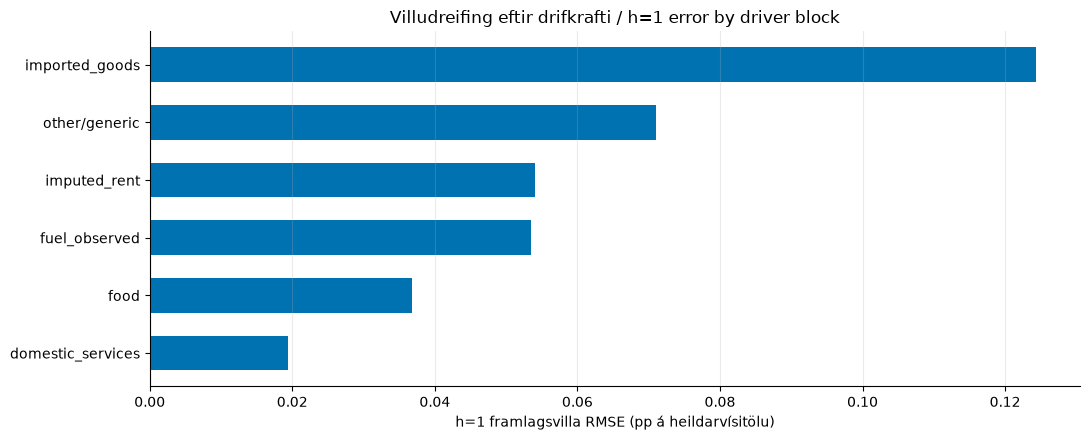

In [5]:
be = backtest.h1_block_error()
display(be.round(4))
fig, ax = plt.subplots()
b = be.sort_values("rmse")
ax.barh(b.index, b["rmse"], color=C["blue"], height=0.6)
ax.set_xlabel("h=1 framlagsvilla RMSE (pp á heildarvísitölu)")
ax.set_title("Villudreifing eftir drifkrafti / h=1 error by driver block")
ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.show()


## Benchmarks that need a market feed

The plan's remaining benchmarks are not machine-accessible here:
- **Breakeven inflation (RIKS vs RIKB)** — the tradeable benchmark and the whole
  economic point (the h=3–12 edge, where breakevens carry an inflation-risk
  premium and an indexed-bond scarcity premium). Clean source: a market feed
  (LSEG connector — needs auth; or Keldan/Kodiak). Seðlabanki publishes
  verðbólguálag only inside monetary-policy reports, not the open data API.
- **Bank analysts** (Íslandsbanki Greining, Landsbankinn, Arion) and **Seðlabanki
  Peningamál** — published in notes/PDFs.

Both are wired to committed CSV slots (`data/benchmarks/`). The comparison code is
ready; only the data is pending — populate the slot and the model-vs-breakeven
decomposition lights up automatically.


In [6]:
from vnv import benchmarks
print("breakeven rows:", len(benchmarks.load_breakeven()),
      "| analyst rows:", len(benchmarks.load_analyst_forecasts()))
print("slot:", benchmarks.write_templates())
print("model_vs_breakeven:", benchmarks.model_vs_breakeven(4.4))  # None until populated


breakeven rows: 0 | analyst rows: 0
slot: C:\Users\admin\Documents\repo\CPI-Analysis\data\benchmarks
model_vs_breakeven: None


## The monthly one-pager

In [7]:
from vnv import report
rep = report.build_report()
from IPython.display import Markdown
Markdown(report.to_markdown(rep))


# VNV spá / CPI forecast — 2026-07

**Núspá 2026-08 (m/m):** +0.28%  
**12-mánaða verðbólga / 12-month inflation:** 4.4%  (90% bil 2.8–6.0%)

## Framlag eftir drifkrafti / Contribution by driver block (12m, pp)

| Blokk / Block | Framlag / Contribution (pp) |
|---|---|
| Reiknuð húsaleiga / Imputed rent | +1.35 |
| Annað / Other | +0.94 |
| Matur & drykkur / Food & beverages | +0.74 |
| Innlend þjónusta / Domestic services | +0.58 |
| Innfluttar vörur / Imported goods | +0.16 |
| Flugfargjöld / Airfares | +0.13 |
| Eldsneyti / Fuel | +0.07 |

## Verðtrygging (VNV í t → verðtrygging í t+2)

| Mánuður | VNV (spá) |
|---|---|
| 2026-10 | 695.2 |
| 2026-11 | 696.1 |
| 2026-12 | 699.1 |
| 2027-01 | 699.5 |
| … | … |

## Módel vs breakeven / Model vs breakeven

_Breakeven slot óupppfyllt — sjá data/benchmarks/breakeven.csv (needs LSEG/Keldan feed)._

## The model is complete — all seven phases

| Phase | Deliverable | Status |
|---|---|---|
| 1 | Ingestion + weight panel | ✅ |
| 2 | Index reconstruction (hard gate) | ✅ all gates pass |
| 3 | Observable nowcast (fuel live; airfares + groceries collecting) | ✅ |
| 4 | Imputed-rent model (HMS) | ✅ beats RW/AR(1) |
| 5 | Driver blocks (FX pass-through) + wage calendar | ✅ |
| 6 | Top-down + MinT reconciliation | ✅ |
| 7 | Backtest, benchmarks, monthly report | ✅ |

**The one remaining data dependency** is the breakeven feed (LSEG/Keldan) for the
tradeable-benchmark comparison — a data-access step, not a modelling one. The two
observable feeds still maturing (airfares, groceries) will sharpen h=1 as their
collection windows accumulate. Everything else is live end to end: from Hagstofa
PxWeb through reconstruction, component models, observables, reconciliation, to
the monthly one-pager.
